In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [17]:
df_vs = pd.read_csv('../20240710-visual servo/experiment_data2.csv')
df_model = pd.read_csv('../20240620-Soft Model/experiment_data3.csv')

loss_vs = np.loadtxt('../20240710-visual servo/loss_list2.csv')
loss_model = np.loadtxt('../20240620-Soft Model/loss_list3.csv')

dot_pixel_np_vs = np.loadtxt('../20240710-visual servo/dot_pixel_list2.csv', delimiter=',')
dot_pixel_np_model = np.loadtxt('../20240620-Soft Model/dot_pixel_list3.csv', delimiter=',')
dot_pixel_np_vs -= dot_pixel_np_vs[0,:]
dot_pixel_np_model -= dot_pixel_np_model[0,:]

rob_mov_np_vs = np.loadtxt('../20240710-visual servo/rob_movement_list2.csv', delimiter=',')
rob_mov_np_model = np.loadtxt('../20240620-Soft Model/rob_movement_list3.csv', delimiter=',')

rob_pos_x_vs = df_vs['actual_TCP_pose_0'].to_numpy()
rob_pos_y_vs = df_vs['actual_TCP_pose_1'].to_numpy()
rob_pos_x_vs -= rob_pos_x_vs[0]
rob_pos_y_vs -= rob_pos_y_vs[0]

rob_pos_x_model = df_model['actual_TCP_pose_0'].to_numpy()
rob_pos_y_model = df_model['actual_TCP_pose_1'].to_numpy()
rob_pos_x_model -= rob_pos_x_model[0]
rob_pos_y_model -= rob_pos_y_model[0]


In [5]:
time = df_vs['timestamp'].to_numpy()
time -= time[0]

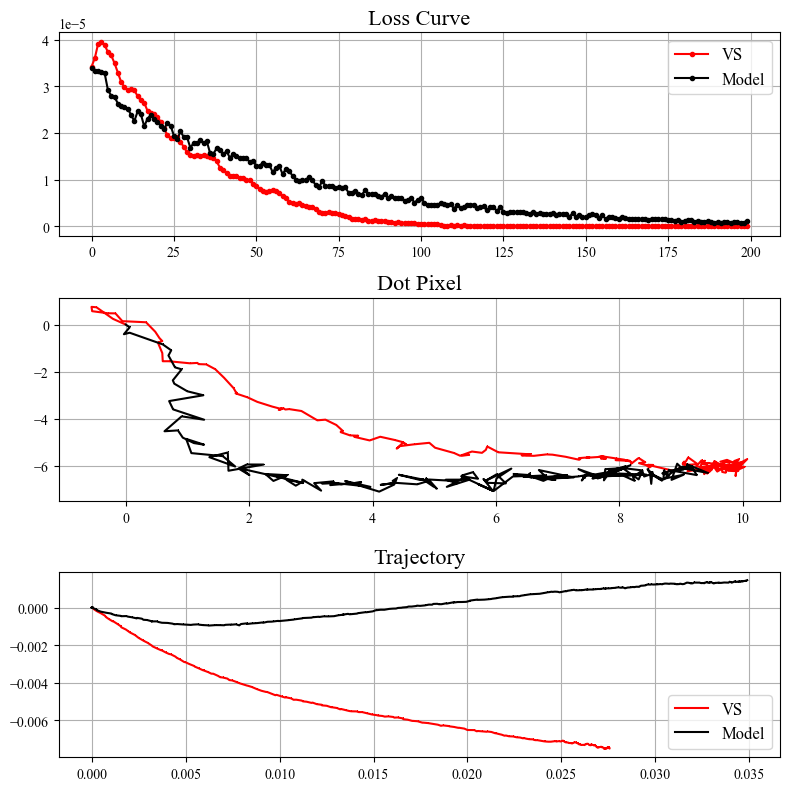

In [22]:
fig = plt.figure(figsize=(8, 8), dpi=100)
gs = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[1, 1, 1])

ax_loss = fig.add_subplot(gs[0])
ax_marker = fig.add_subplot(gs[1])
ax_traj = fig.add_subplot(gs[2])

ax_loss.plot(loss_vs, marker='.', linestyle='-', color='r', label='VS')
ax_loss.set_title('Loss Curve', fontsize=16)
ax_loss.plot(loss_model, marker='.', linestyle='-', color='k', label='Model')
ax_loss.legend(loc='upper right', fontsize=12)

ax_marker.plot(dot_pixel_np_vs[:,0], dot_pixel_np_vs[:,1], marker=',', linestyle='-', color='r', label='VS')
ax_marker.plot(dot_pixel_np_model[:,0], dot_pixel_np_model[:,1], marker=',', linestyle='-', color='k', label='Model')
ax_marker.set_title('Dot Pixel', fontsize=16)

sample_rate = 50
ax_traj.plot(-rob_pos_x_vs[::sample_rate], rob_pos_y_vs[::sample_rate], marker=',', linestyle='-', color='r', label='VS')
ax_traj.plot(-rob_pos_x_model[::sample_rate], rob_pos_y_model[::sample_rate], marker=',', linestyle='-', color='k', label='Model')
ax_traj.set_title('Trajectory', fontsize=16)
ax_traj.legend(loc='lower right', fontsize=12)
ax_traj.set_aspect('equal', 'box')

axs = [ax_loss, ax_marker, ax_traj]
for ax in axs:
    ax.grid(True)

plt.tight_layout()